In [1]:
import matplotlib.pyplot as plt
import shap
import lime 
import lime.lime_tabular
import numpy as np
import pandas as pd
import joblib


In [2]:
xgb_model = joblib.load('xgb_model.pkl')
scaler = joblib.load('scaler.pkl')

df = pd.read_csv('loan_ml_ready_dataset.csv')

df.columns = df.columns.str.replace('[', '', regex=False)
df.columns = df.columns.str.replace(']', '', regex=False)
df.columns = df.columns.str.replace('<', '', regex=False)

X = df.drop(columns=['loan_status'])
Y = df['loan_status']

print("Everything Loaded")
print("Shape: ", X.shape)

Everything Loaded
Shape:  (1345310, 200)


In [3]:
X = X.astype({col: 'int64' for col in X.select_dtypes('bool').columns})
print("Booleans converted!")
print(X.dtypes.value_counts())

Booleans converted!
int64      125
float64     75
Name: count, dtype: int64


In [4]:
print(X.dtypes.value_counts())
print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=['float64', 'int64']).columns.tolist())

int64      125
float64     75
Name: count, dtype: int64

Non-numeric columns:
[]


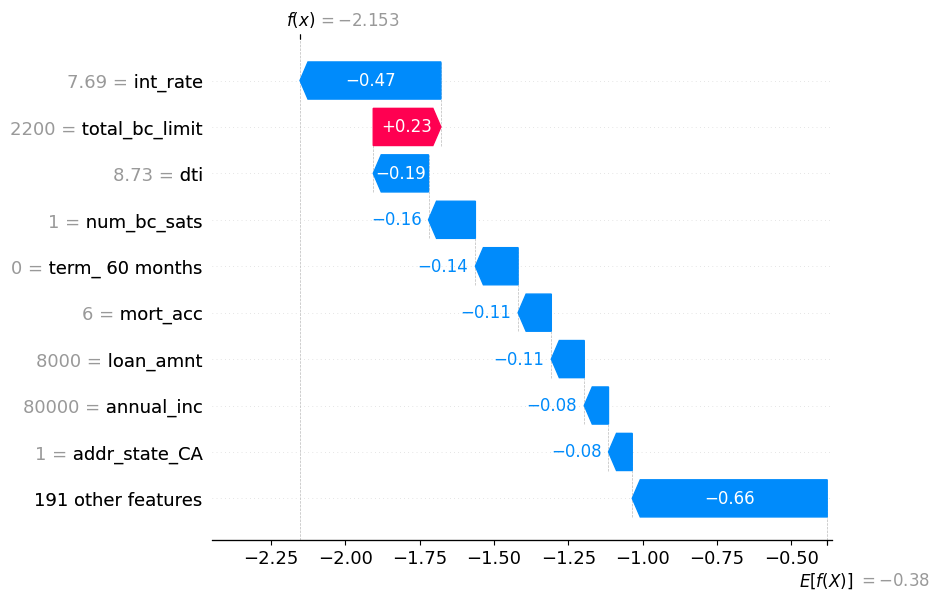

In [5]:
X_sample = X.sample(500, random_state=42)
X_sample = X_sample.apply(pd.to_numeric, errors='coerce')
X_sample = X_sample.fillna(0)

explainer = shap.Explainer(xgb_model, X_sample)
shap_values = explainer(X_sample)

shap.plots.waterfall(shap_values[0])

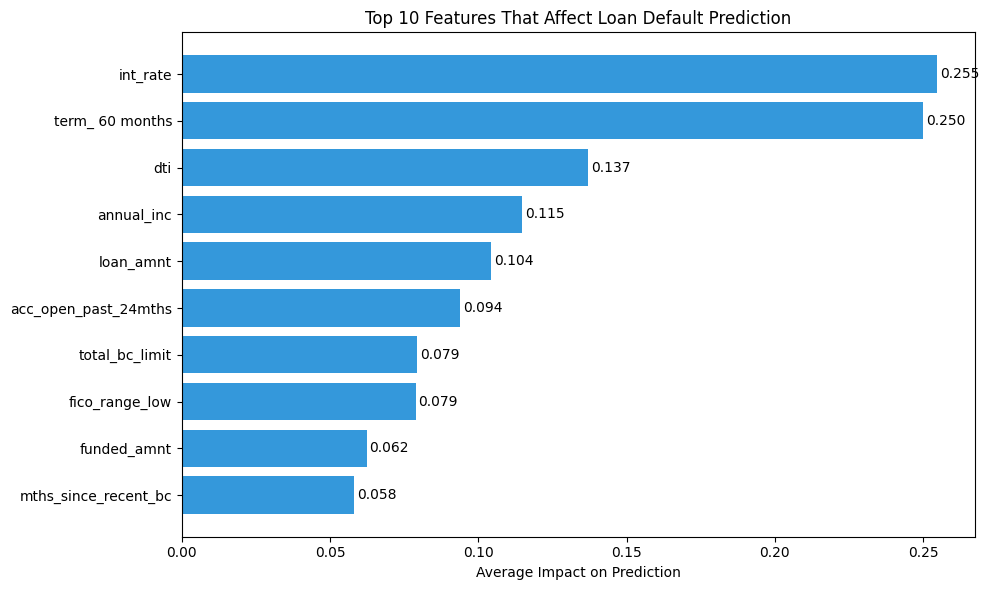

In [6]:
shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': np.abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(shap_importance['feature'], shap_importance['importance'], color='#3498db')
plt.xlabel('Average Impact on Prediction')
plt.title('Top 10 Features That Affect Loan Default Prediction')
plt.gca().invert_yaxis()

for bar, val in zip(bars, shap_importance['importance']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

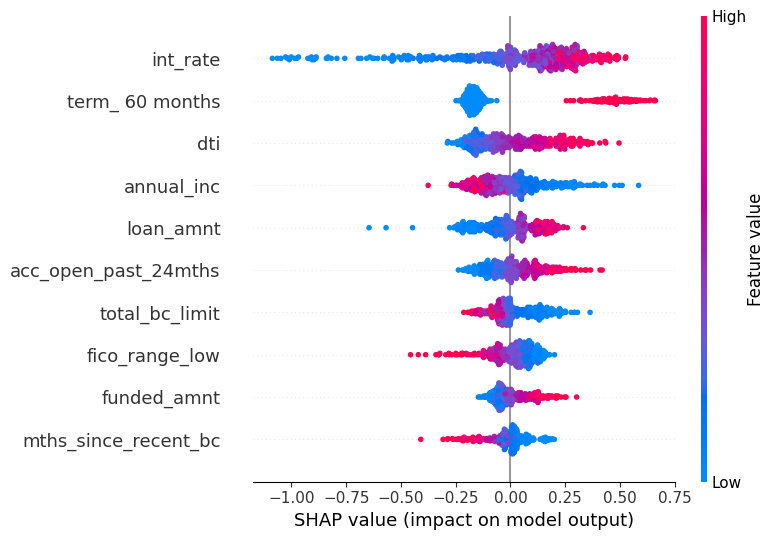

In [7]:
shap.summary_plot(shap_values.values, X_sample, max_display=10)

In [10]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_sample.values,
    feature_names=X_sample.columns.tolist(),
    class_names=['Repaid', 'Defaulted'],
    mode='classification'
)

print("LIME Explainer Ready!")

LIME Explainer Ready!


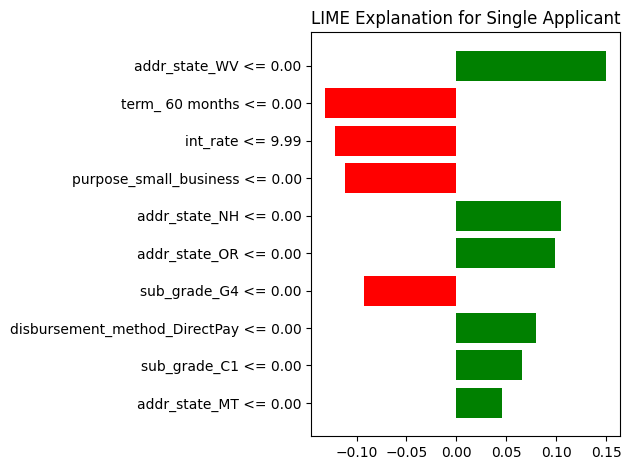

In [13]:
person = X_sample.iloc[0].values

explanation = lime_explainer.explain_instance(
    data_row=person,
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

explanation.as_pyplot_figure()
plt.title('LIME Explanation for Single Applicant')
plt.tight_layout()
plt.show()

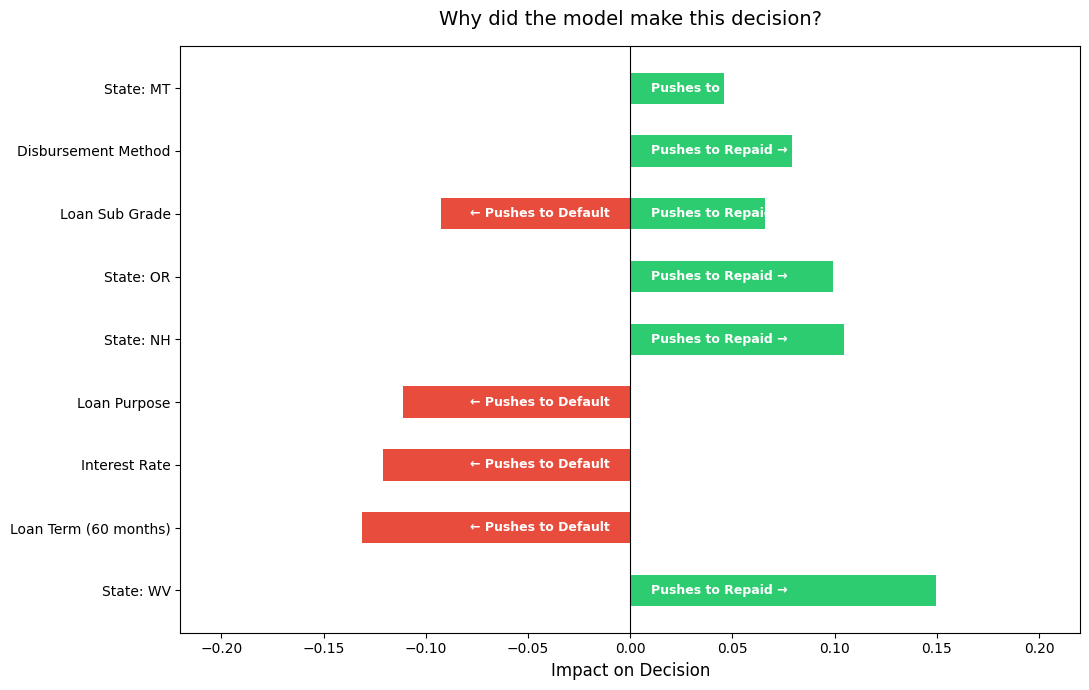

In [15]:
exp_list = explanation.as_list()

features = [item[0] for item in exp_list]
values = [item[1] for item in exp_list]
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]

simple_features = []
for f in features:
    if 'int_rate' in f:
        simple_features.append('Interest Rate')
    elif 'term_' in f:
        simple_features.append('Loan Term (60 months)')
    elif 'dti' in f:
        simple_features.append('Debt-to-Income Ratio')
    elif 'annual_inc' in f:
        simple_features.append('Annual Income')
    elif 'loan_amnt' in f:
        simple_features.append('Loan Amount')
    elif 'fico' in f:
        simple_features.append('Credit Score')
    elif 'purpose' in f:
        simple_features.append('Loan Purpose')
    elif 'emp_length' in f:
        simple_features.append('Employment Length')
    elif 'sub_grade' in f:
        simple_features.append('Loan Sub Grade')
    elif 'disbursement' in f:
        simple_features.append('Disbursement Method')
    elif 'addr_state' in f:
        state = f.split('addr_state_')[1].split(' ')[0]
        simple_features.append(f'State: {state}')
    else:
        simple_features.append(f.split('<=')[0].split('>')[0].strip())

plt.figure(figsize=(11, 7))
bars = plt.barh(simple_features, values, color=colors, height=0.5)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Impact on Decision', fontsize=12)
plt.title('Why did the model make this decision?', fontsize=14, pad=15)
plt.xlim(-0.22, 0.22)

for bar, val in zip(bars, values):
    label = '← Pushes to Default' if val < 0 else 'Pushes to Repaid →'
    x_pos = -0.01 if val < 0 else 0.01
    ha = 'right' if val < 0 else 'left'
    plt.text(x_pos, bar.get_y() + bar.get_height()/2,
             label, va='center', fontsize=9, ha=ha, color='white', fontweight='bold')

plt.tight_layout()
plt.show()